<a href="https://colab.research.google.com/github/SERGIOHEREDIA07/TAREAS/blob/master/TDAPOLINOMIO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

class Polinomio:
    def __init__(self, coeficientes):
        """
        coeficientes: lista donde el índice es el grado
        Ej: [2, 3, 1] => 2 + 3x + x^2
        """
        self.coef = coeficientes
        self._limpiar()

    def _limpiar(self):
        """Elimina ceros innecesarios al final"""
        while len(self.coef) > 1 and self.coef[-1] == 0:
            self.coef.pop()

    def grado(self):
        return len(self.coef) - 1

    def __str__(self):
        términos = []
        for i, c in enumerate(self.coef):
            if c != 0:
                if i == 0:
                    términos.append(f"{c}")
                elif i == 1:
                    términos.append(f"{c}x")
                else:
                    términos.append(f"{c}x^{i}")
        return " + ".join(términos[::-1]) if términos else "0"

    def evaluar(self, x):
        resultado = 0
        for i, c in enumerate(self.coef):
            resultado += c * (x ** i)
        return resultado

    def __add__(self, otro):
        max_len = max(len(self.coef), len(otro.coef))
        nuevo = [0] * max_len
        for i in range(max_len):
            a = self.coef[i] if i < len(self.coef) else 0
            b = otro.coef[i] if i < len(otro.coef) else 0
            nuevo[i] = a + b
        return Polinomio(nuevo)

    def __sub__(self, otro):
        max_len = max(len(self.coef), len(otro.coef))
        nuevo = [0] * max_len
        for i in range(max_len):
            a = self.coef[i] if i < len(self.coef) else 0
            b = otro.coef[i] if i < len(otro.coef) else 0
            nuevo[i] = a - b
        return Polinomio(nuevo)

    def __mul__(self, otro):
        resultado = [0] * (len(self.coef) + len(otro.coef) - 1)
        for i in range(len(self.coef)):
            for j in range(len(otro.coef)):
                resultado[i + j] += self.coef[i] * otro.coef[j]
        return Polinomio(resultado)

    def derivada(self):
        if self.grado() == 0:
            return Polinomio([0])
        deriv = [i * self.coef[i] for i in range(1, len(self.coef))]
        return Polinomio(deriv)

    def integral(self, constante=0):
        integ = [constante]
        for i in range(len(self.coef)):
            integ.append(self.coef[i] / (i + 1))
        return Polinomio(integ)

    def encontrar_raiz(self, x0=0, tolerancia=1e-6, max_iter=100):
        """Método de Newton-Raphson"""
        x = x0
        for _ in range(max_iter):
            fx = self.evaluar(x)
            dfx = self.derivada().evaluar(x)
            if dfx == 0:
                return None
            x_new = x - fx / dfx
            if abs(x_new - x) < tolerancia:
                return x_new
            x = x_new
        return None

    def graficar(self, x_min=-10, x_max=10, pasos=1000):
        """Dibuja el polinomio usando matplotlib"""
        x = np.linspace(x_min, x_max, pasos)
        y = np.array([self.evaluar(xi) for xi in x])
        plt.figure(figsize=(8,5))
        plt.plot(x, y, label=str(self))
        plt.axhline(0, color='black', linewidth=1)
        plt.axvline(0, color='black', linewidth=1)
        plt.title("Gráfica del Polinomio")
        plt.xlabel("x")
        plt.ylabel("P(x)")
        plt.legend()
        plt.grid(True)
        plt.show()

Polinomio: 1x^2 + -3x + 2
Grado: 2
P(2): 0
Derivada: 2x + -3
Integral: 0.3333333333333333x^3 + -1.5x^2 + 2.0x


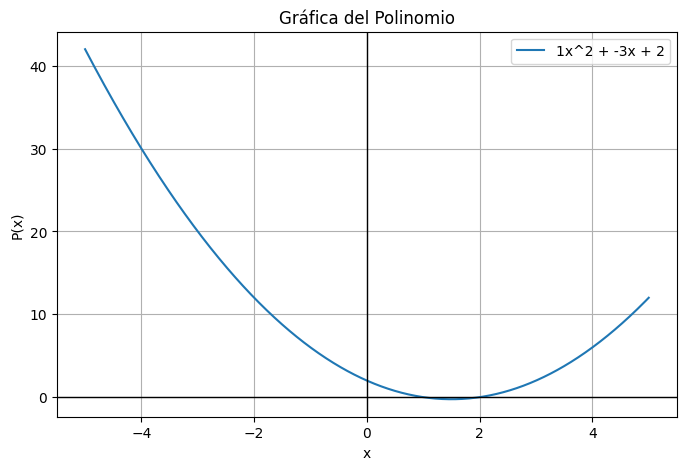

Raíz aproximada: 0.9999999999999998


In [ ]:
# Crear polinomios
p1 = Polinomio([2, -3, 1])  # 2 - 3x + x^2

print("Polinomio:", p1)
print("Grado:", p1.grado())
print("P(2):", p1.evaluar(2))
print("Derivada:", p1.derivada())
print("Integral:", p1.integral())

# Graficar el polinomio
p1.graficar(x_min=-5, x_max=5)

# Encontrar una raíz aproximada
raiz = p1.encontrar_raiz(0)
print("Raíz aproximada:", raiz)